# Recalculating Coastal Upwelling Transport Index (CUTI), Jacox et al., (2018)

For CUTI we need the Ekman net contribution ($Ek_{int}$) + the geostrophic part ($U_{geo}$)

* For the $Ek_{int}$ we integrate the boundaries at every 1 degree perimeter, let the equations be as follow:

\
\begin{aligned}
Q^{(E)}_{E} &= \int_{y_1}^{y_2} U_E(x_E,y)\,dy, = 0 \\
Q^{(W)}_{E} &= - \int_{y_1}^{y_2} U_E(x_W,y)\,dy, \\
Q^{(N)}_{E} &= \int_{x_W}^{x_E} V_E(x,y_2)\,dx, \\
Q^{(S)}_{E} &= - \int_{x_W}^{x_E} V_E(x,y_1)\,dx, \\
Q_{\mathrm{div}}
&= Q^{(E)}_{E} + Q^{(W)}_{E} + Q^{(N)}_{E} + Q^{(S)}_{E}
= \iint\limits_{A} \nabla \!\cdot\! \mathbf{M}_E \, dA, \\
\bar{w}_E
&= \frac{Q_{\mathrm{div}}}{A}
= \frac{1}{\rho\,f}\, \bigl(\nabla \times \boldsymbol{\tau}\bigr)_z .
\end{aligned}

* For geostrophic transport ($U_{geo}$), $\Delta \mathrm{SSH}$ is the difference between the coastal SSH values at the northernmost and southernmost grid points within the 1° segment. The $MLD$ is defined as the width of the Rossby radius of deformation (30 km; R1).

$$
\begin{aligned}
u_{\mathrm{geo}} &= \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}, \\[1ex]
\mathbf{U}_{\mathrm{geo}} &= \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}, \\[1ex]
\text{CUTI} &= U_{\text{ek}} + U_{\text{geo}} \\
&= \frac{\nabla \tau}{\rho_w f} \cdot \hat{k} - \frac{gD}{f} \frac{\partial \eta}{\partial y}.
\end{aligned}
$$

where $g$ is the gravitational acceleration, $D$ is the Ekman layer depth, and $d$ is distance to the coast.

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm 

## Functions

In [2]:
# mask
def coastal_band_mask(ds, var='u10', iterations=10):
    """
    Create a coastal band mask by dilating the coastline edge.

    Parameters
    ----------
    ds : xr.Dataset
        Must contain 2D lat/lon coords and the target variable.
    var : str
        Variable name used to detect land (NaN) vs ocean.
    iterations : int
        Number of dilation steps (~10 km per iteration on a ~10 km grid).

    Returns
    -------
    da_mask : xr.DataArray
        Boolean mask (True inside the coastal band).
    """
    valid2d = np.isfinite(ds[var].mean(dim='time')).values.astype(bool)

    eroded = binary_erosion(valid2d, structure=np.ones((3, 3)), iterations=1)
    coast = valid2d & (~eroded)

    band = binary_dilation(coast, structure=np.ones((3, 3)), iterations=iterations) & valid2d

    da_mask = xr.DataArray(
        band,
        dims=('lat', 'lon'),
        coords={'lat': ds['lat'], 'lon': ds['lon']},
    )
    return da_mask

In [3]:
def lat_band_mean(
    f,
    lat_top_start=-4,
    lat_top_end=-17,
):
    """
    Compute (f_north + f_south)/2 for successive 1° latitude bands.

    Parameters
    ----------
    f : xarray.DataArray
        Must have a 'lat' dimension (and optionally time/lon/etc.).
    lat_top_start : float or int
        Northern latitude of the first band (e.g. -5).
    lat_top_end : float or int
        Northern latitude of the last band (e.g. -16).

    Returns
    -------
    f_band : xarray.DataArray
        delta_f for each 1° band, with new dimension 'lat_band'.
        Any other original dimensions (e.g. time) are preserved.
    """

    delta_f = []
    lat_band_centers = []

    for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):
        lat_south = lat_north - 1

        # 1° band slice
        f_band = f.sel(lat=slice(lat_south, lat_north))

        # skip bands with no points
        if f_band.sizes.get("lat", 0) == 0:
            continue

        southernmost = f_band.isel(lat=0)
        northernmost = f_band.isel(lat=1)

        delta_f.append((northernmost + southernmost) / 2)
        lat_band_centers.append(0.5 * (lat_south + lat_north))

    # concat over bands
    f_out = xr.concat(delta_f, dim="lat_band")
    f_out = f_out.assign_coords(lat_band=np.array(lat_band_centers))
    f_out.name = "delta_f"

    return f_out

In [4]:
## seasonality
def seasonality(data):    
    season = data.groupby('time.month').mean(dim='time')
    return season

## Data

In [5]:
ds = xr.open_dataset('winds_and_components.nc')
ds

<xarray.Dataset> Size: 8GB
Dimensions:            (lon: 602, lat: 542, time: 432)
Coordinates:
  * lon                (lon) float64 5kB -119.0 -118.9 -118.8 ... -68.95 -68.87
  * lat                (lat) float64 4kB -33.0 -32.93 -32.86 ... 9.951 10.03
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 1GB ...
    v10                (time, lat, lon) float64 1GB ...
    tau_alongshore     (time, lat, lon) float64 1GB ...
    Uekman_Crossshore  (time, lat, lon) float64 1GB ...
    Inshore_Uekman     (time, lat, lon) float64 1GB ...
    Uek_geo            (time, lat, lon) float64 1GB ...
    Vek_geo            (time, lat, lon) float64 1GB ...
    f                  (lat) float64 4kB ...

## Uekman or $Ek_{int}$ calculation
* We are using the non-rotated geographical Uekman_geo and Vekman_geo

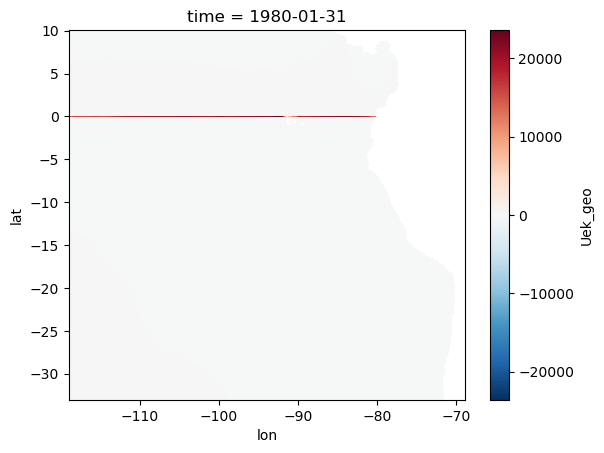

In [6]:
ds.Uek_geo.isel(time=0).plot()

In [7]:
## 111km mask or (1/12)*10*111 km
mask = coastal_band_mask(ds, var='Uek_geo', iterations=10)

wind_coastal = ds.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4)) 
wind_coastal

<xarray.Dataset> Size: 925MB
Dimensions:            (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon                (lon) float64 2kB -84.95 -84.87 -84.78 ... -68.95 -68.87
  * lat                (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.162 -4.079
  * time               (time) datetime64[ns] 3kB 1980-01-31 ... 2015-12-31
Data variables:
    u10                (time, lat, lon) float64 132MB nan nan nan ... nan nan
    v10                (time, lat, lon) float64 132MB nan nan nan ... nan nan
    tau_alongshore     (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Uekman_Crossshore  (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Inshore_Uekman     (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Uek_geo            (time, lat, lon) float64 132MB nan nan nan ... nan nan
    Vek_geo            (time, lat, lon) float64 132MB nan nan nan ... nan nan
    f                  (lat, lon) float64 306kB nan nan nan nan ... nan nan nan

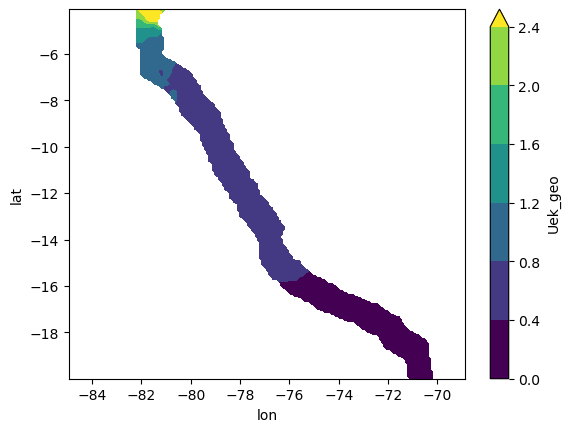

In [8]:
wind_coastal.Uek_geo.std('time').plot.contourf(robust=True)

In [9]:
wind_coastal.lat

<xarray.DataArray 'lat' (lat: 197)> Size: 2kB
array([-19.994865, -19.916554, -19.838205, -19.759817, -19.681391, -19.602926,
       -19.524422, -19.445881, -19.367301, -19.288683, -19.210028, -19.131335,
       -19.052604, -18.973836, -18.89503 , -18.816187, -18.737307, -18.658391,
       -18.579437, -18.500447, -18.42142 , -18.342357, -18.263257, -18.184122,
       -18.10495 , -18.025743, -17.9465  , -17.867221, -17.787907, -17.708557,
       -17.629173, -17.549753, -17.470298, -17.390809, -17.311285, -17.231727,
       -17.152134, -17.072507, -16.992845, -16.91315 , -16.833421, -16.753659,
       -16.673863, -16.594033, -16.514171, -16.434275, -16.354346, -16.274384,
       -16.19439 , -16.114364, -16.034304, -15.954213, -15.87409 , -15.793934,
       -15.713747, -15.633528, -15.553278, -15.472996, -15.392683, -15.312339,
       -15.231964, -15.151558, -15.071121, -14.990654, -14.910157, -14.829629,
       -14.749072, -14.668484, -14.587867, -14.50722 , -14.426544, -14.345838,
       -14.265103, -14.18434 , -14.103547, -14.022725, -13.941875, -13.860997,
       -13.78009 , -13.699156, -13.618193, -13.537202, -13.456184, -13.375139,
       -13.294066, -13.212965, -13.131838, -13.050684, -12.969503, -12.888295,
       -12.807062, -12.725801, -12.644515, -12.563203, -12.481865, -12.400501,
       -12.319112, -12.237697, -12.156258, -12.074793, -11.993303, -11.911789,
       -11.83025 , -11.748687, -11.667099, -11.585488, -11.503852, -11.422193,
       -11.34051 , -11.258804, -11.177074, -11.095321, -11.013546, -10.931747,
       -10.849926, -10.768082, -10.686216, -10.604328, -10.522418, -10.440486,
       -10.358533, -10.276557, -10.194561, -10.112543, -10.030505,  -9.948445,
        -9.866365,  -9.784264,  -9.702143,  -9.620001,  -9.53784 ,  -9.455658,
        -9.373457,  -9.291237,  -9.208997,  -9.126737,  -9.044459,  -8.962162,
        -8.879846,  -8.797511,  -8.715158,  -8.632787,  -8.550398,  -8.467991,
        -8.385566,  -8.303124,  -8.220664,  -8.138187,  -8.055693,  -7.973182,
        -7.890654,  -7.808109,  -7.725549,  -7.642972,  -7.560379,  -7.47777 ,
        -7.395145,  -7.312505,  -7.22985 ,  -7.147179,  -7.064493,  -6.981792,
        -6.899077,  -6.816347,  -6.733603,  -6.650844,  -6.568072,  -6.485285,
        -6.402485,  -6.319671,  -6.236845,  -6.154004,  -6.071151,  -5.988285,
        -5.905407,  -5.822516,  -5.739612,  -5.656697,  -5.573769,  -5.49083 ,
        -5.407879,  -5.324916,  -5.241943,  -5.158958,  -5.075962,  -4.992956,
        -4.909939,  -4.826911,  -4.743873,  -4.660825,  -4.577768,  -4.4947  ,
        -4.411623,  -4.328537,  -4.245441,  -4.162336,  -4.079223])
Coordinates:
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079

### Now the $Ek_{int}$

In [10]:
def qdiv_for_band(Uek, Vek,
                  lat_south, lat_north,
                  lon_west=-83, lon_east=-70,
                  delta_y=9250, delta_x=9250, N=12):

    Uek_ = Uek.sel(lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east))
    Vek_ = Vek.sel(lat=slice(lat_south, lat_north), lon=slice(lon_west, lon_east))

    # Boolean mask of valid ocean cells
    valid = xr.where(np.isfinite(Uek_), 1, 0)
    valid_e = valid.shift(lon=-1)
    valid_w = valid.shift(lon=+1)
    west_mask = (valid == 1) & (valid_w == 0)
    east_mask = (valid == 1) & (valid_e == 0)

    easternmost  = Uek_.where(east_mask)
    westernmost  = Uek_.where(west_mask)
    southernmost = Vek_.isel(lat=0)     # actual southern boundary
    northernmost = Vek_.isel(lat=-1)    # actual northern boundary

    QE = (easternmost.mean('lon')
          .rolling(lat=2, center=False)
          .mean(skipna=True).sum(dim='lat') * delta_y)

    QW = -(westernmost.mean('lon')
           .rolling(lat=2, center=False)
           .mean(skipna=True).sum(dim='lat') * delta_y)

    QN = (northernmost
          .rolling(lon=2, center=False)
          .mean(skipna=True).sum(dim='lon') * delta_x)

    QS = -(southernmost
           .rolling(lon=2, center=False)
           .mean(skipna=True).sum(dim='lon') * delta_x)

    Qdiv = (QW + QS + QN) / (delta_x * (N - 1))
    return Qdiv

In [11]:
lat_top_start = -4   # first northern edge
lat_top_end   = -17  # last northern edge

results = []
lat_band_centers = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    Qdiv_band = qdiv_for_band(
        wind_coastal.Uek_geo, wind_coastal.Vek_geo,
        lat_south=lat_south, lat_north=lat_north,
        lon_west=-83, lon_east=-70,
        delta_y=9250, delta_x=9250, N=12
    )

    results.append(Qdiv_band)
    lat_band_centers.append(0.5 * (lat_south + lat_north))
    
Qdiv_all = xr.concat(results, dim='lat_band')

U_ek = Qdiv_all.assign_coords(lat_band=lat_band_centers)

100%|████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 45.90it/s]


In [12]:
U_ek

<xarray.DataArray (lat_band: 14, time: 432)> Size: 48kB
array([[1.72191702, 0.8575783 , 0.57820832, ..., 3.01958607, 3.62946611,
        2.78920483],
       [2.23172049, 1.28880271, 0.98895432, ..., 4.67677826, 4.85026067,
        4.15045763],
       [1.23404502, 0.7392373 , 0.29148548, ..., 2.83446529, 2.85913763,
        2.22306861],
       ...,
       [0.99237314, 0.76794561, 0.72630737, ..., 1.58380965, 1.51228175,
        1.29307982],
       [1.73887729, 1.28905883, 1.1267795 , ..., 2.48607189, 2.59630417,
        2.24885116],
       [1.75202549, 1.77245608, 1.6698207 , ..., 2.60269321, 2.51683335,
        2.14651126]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 112B -4.5 -5.5 -6.5 -7.5 ... -15.5 -16.5 -17.5

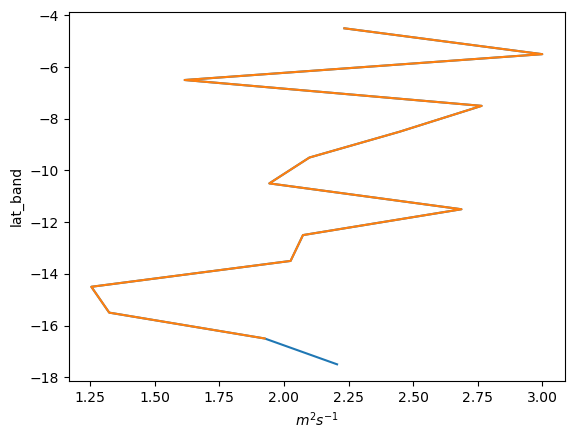

In [13]:
(U_ek).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')
U_ek.sel(lat_band=slice(-4,-17)).mean('time').rename('$m^{2}s^{-1}$').plot(y='lat_band')

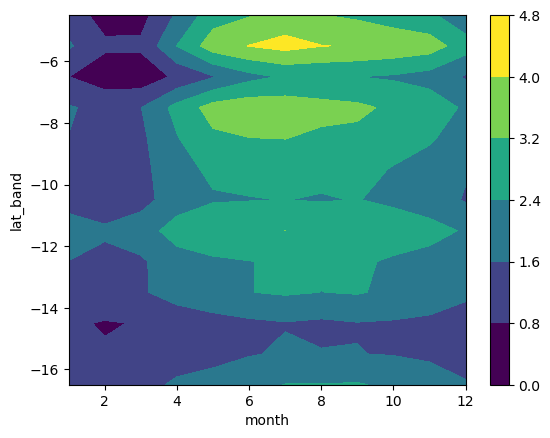

In [14]:
seasonality(U_ek).sel(lat_band=slice(-4,-17)).plot.contourf(x='month')

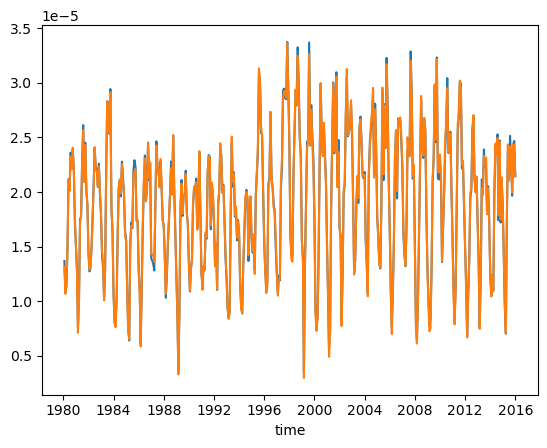

In [15]:
# d = (10/12)*111*1000
d = 111*1000
(U_ek.mean(dim='lat_band')/d).plot()
((U_ek.sel(lat_band=slice(-5,-16))).mean(dim='lat_band')/d).plot()

In [16]:
wmld = xr.open_dataset('W_mld_Croco.nc').compute()
wmld = wmld.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

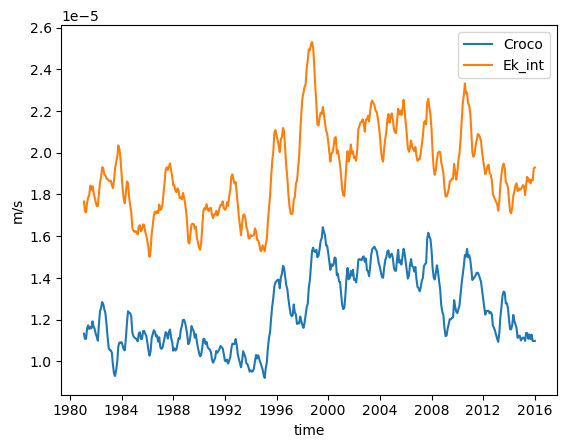

In [17]:
import matplotlib.pyplot as plt

wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco')
(((U_ek)).mean(dim='lat_band')/d).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
plt.legend()

## Now the Geostrophic Velocity

$
u_{\mathrm{geo}} = \frac{g}{f}\,\frac{\Delta \mathrm{SSH}}{d_{\mathrm{coast}}}
$

$
\mathbf{U}_{\mathrm{geo}} = \mathbf{u}_{\mathrm{geo}} \times \mathrm{MLD}
$

In [18]:
ssh = xr.open_dataset('SSH.nc').compute()
ssh

<xarray.Dataset> Size: 564MB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
Data variables:
    SSH      (time, lat, lon) float32 564MB 0.212 0.212 0.2117 ... 0.0 0.0 0.0

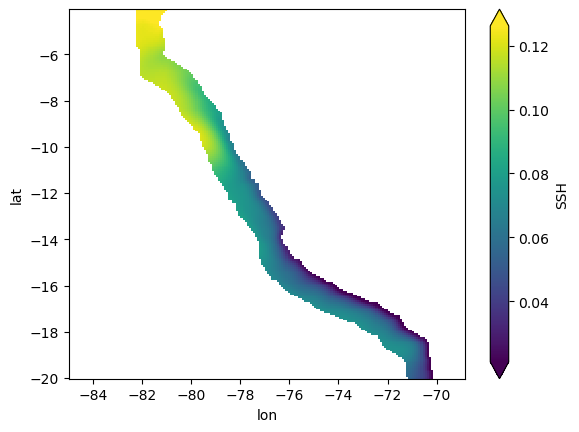

In [19]:
## SSH is in m
ssh = ssh.where(mask).sel(lon=slice(-85,None),lat=slice(-20,-4))
ssh.mean('time').SSH.plot(robust=True)

In [20]:
lat_top_start = -4   # first northern edge
lat_top_end   = -17  # last northern edge

delta_SSH = []
# results_Sv = []

for lat_north in tqdm(range(lat_top_start, lat_top_end - 1, -1)):  # -4, -5, ..., -16
    lat_south = lat_north - 1                                # -5, -6, ..., -17

    # 1° band slice
    SSH_band = ssh.SSH.sel(lat=slice(lat_south, lat_north))

    southernmost = SSH_band.isel(lat=0)
    northernmost = SSH_band.isel(lat=-1)    
    
    delta_SSH.append(northernmost-southernmost)

ssh_ = xr.concat(delta_SSH, dim='lat_band')
ssh_ = ssh_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5 - 1, -1)
)


100%|██████████████████████████████████████████████████████████████████████████████████| 14/14 [00:00<00:00, 1089.71it/s]


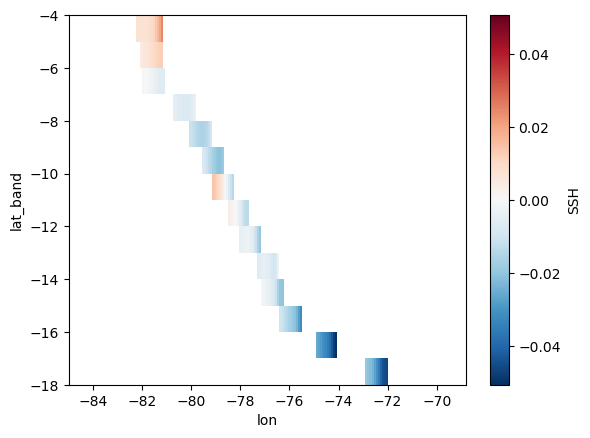

In [21]:
ssh_.mean('time').plot()

In [22]:
lat_centers = np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
Omega = 7.2921e-5
f_ = 2 * Omega * np.sin(np.deg2rad(lat_centers))
f_ = xr.DataArray(f_, dims='lat_band', coords={'lat_band': lat_centers})
f_

<xarray.DataArray (lat_band: 13)> Size: 104B
array([-1.14426314e-05, -1.39783362e-05, -1.65097831e-05, -1.90362009e-05,
       -2.15568201e-05, -2.40708729e-05, -2.65775935e-05, -2.90762183e-05,
       -3.15659862e-05, -3.40461388e-05, -3.65159206e-05, -3.89745792e-05,
       -4.14213659e-05])
Coordinates:
  * lat_band  (lat_band) float64 104B -4.5 -5.5 -6.5 -7.5 ... -14.5 -15.5 -16.5

In [23]:
d_coast = 111*1000#1 grado de latitud en m
g = 9.81

u_geo = (g/f_)*(ssh_/d_coast) #minus sign here 

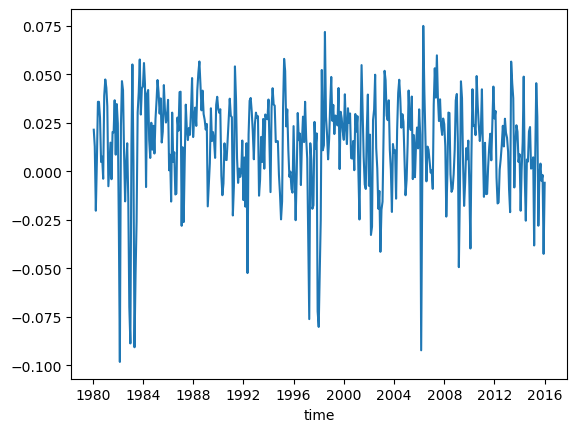

In [24]:
u_geo.mean(dim=('lat_band','lon')).plot()

* The onshore geostrophic flow increased during EN 1997-98

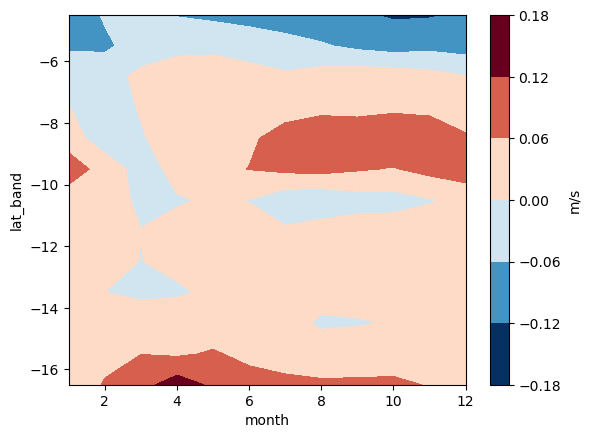

In [25]:
seasonality(u_geo.mean('lon').rename('m/s')).plot.contourf()

### MLD

In [26]:
MLD_ds = xr.open_dataset('MLD.nc').compute()
MLD_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 1GB 0.9402 0.9402 1.335 ... nan nan nan

In [27]:
mask_mld = coastal_band_mask(MLD_ds, var='MLD', iterations=3)
MLD_ds = MLD_ds.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-20,-4))
MLD_ds

<xarray.Dataset> Size: 132MB
Dimensions:  (time: 432, lat: 197, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 2kB -19.99 -19.92 -19.84 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    MLD      (time, lat, lon) float64 132MB nan nan nan nan ... nan nan nan nan

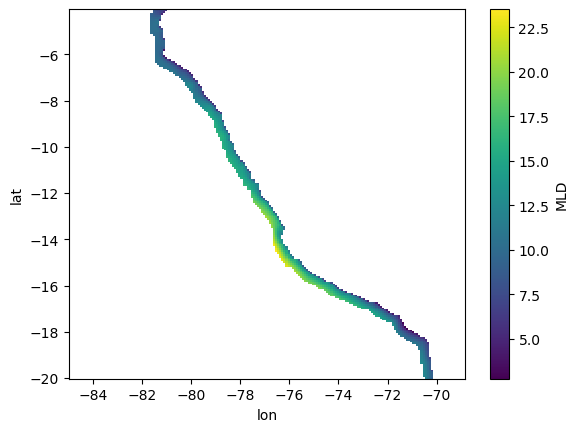

In [28]:
MLD_ds.MLD.std('time').plot()

In [29]:
delta_mld = []

lat_top_start = -4   # first northern edge
lat_top_end   = -17  # last northern edge

for lat_north in tqdm(range(lat_top_start, lat_top_end, -1)):
    lat_south = lat_north - 1
    mld_band = MLD_ds.MLD.sel(lat=slice(lat_south, lat_north)).mean(dim='lat')
    delta_mld.append(mld_band)

mld_ = xr.concat(delta_mld, dim='lat_band')
mld_ = mld_.assign_coords(
    lat_band=np.arange(lat_top_start - 0.5, lat_top_end - 0.5, -1)
)

100%|███████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 246.53it/s]


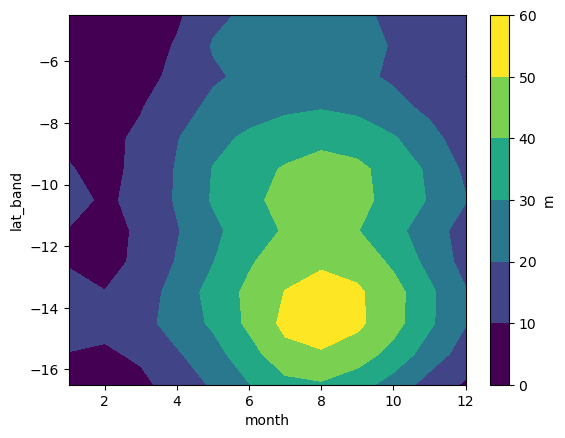

In [30]:
seasonality(mld_.mean(dim=('lon')).rename('m')).plot.contourf()

## $U^{geo}$

Text(0.5, 1.0, '$U^{Geo}$')

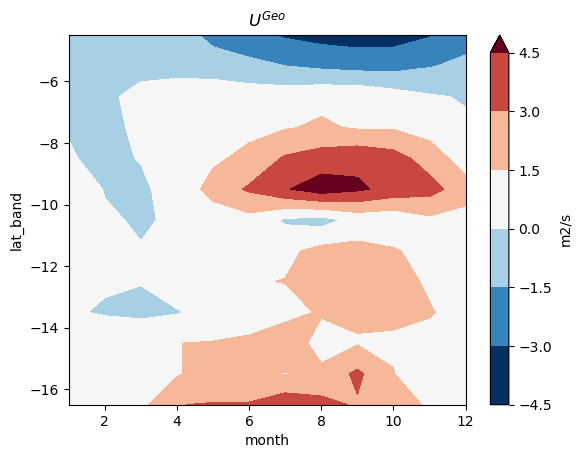

In [31]:
U_geo = (u_geo * mld_)
seasonality((u_geo * mld_).mean(dim='lon')).rename('m2/s').plot.contourf(robust=True)
plt.title('$U^{Geo}$')

## CUTI

$CUTI$ = $U^{Ek}$ + $U^{Geo}$

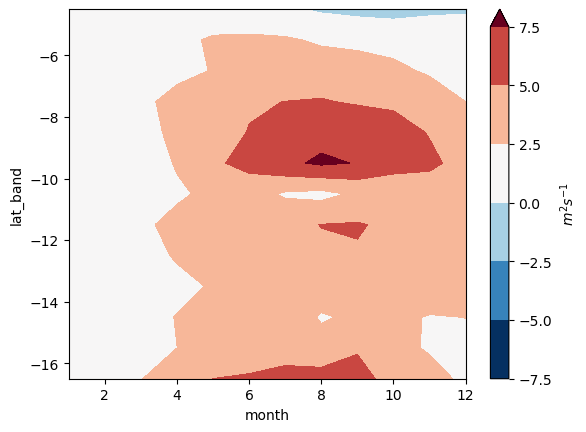

In [32]:
CUTI = U_ek + (U_geo)#m2/s

seasonality(CUTI.mean(dim='lon')).rename('$m^2s^{-1}$').plot.contourf(robust=True)

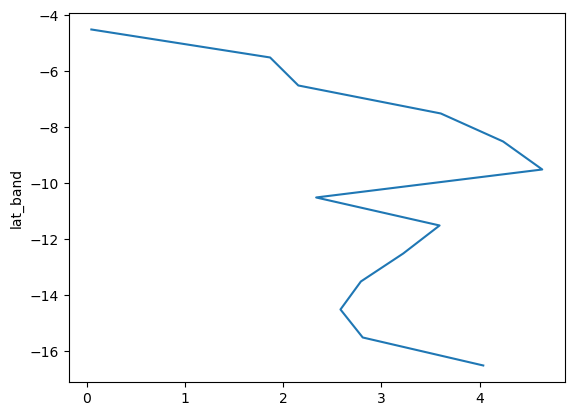

In [33]:
CUTI.mean(dim=('lon','time')).plot(y='lat_band')

In [34]:
d = (1/12)*10*1000*111

In [35]:
wmld2 = xr.open_dataset('W_mld_Croco.nc').compute()
wmld2 = wmld2.where(mask).sel(lon=slice(-85,None),lat=slice(-17,-4))
wmld2

<xarray.Dataset> Size: 107MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
Data variables:
    WMLD     (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [36]:
wmld_ = lat_band_mean(wmld2.WMLD,
    lat_top_start=-5,
    lat_top_end=-16,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 812.88it/s]


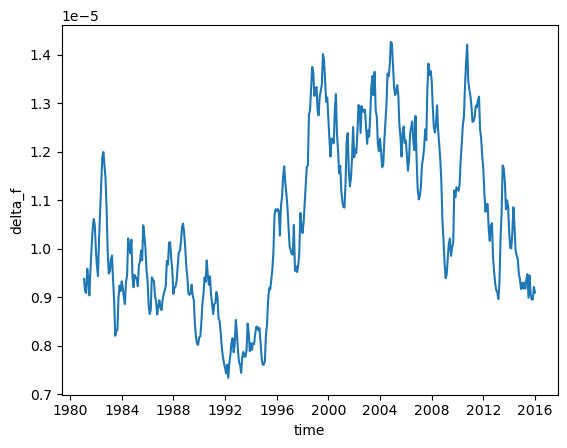

In [37]:
wmld_.mean(dim=('lat_band','lon')).rolling(time=13).mean().plot()

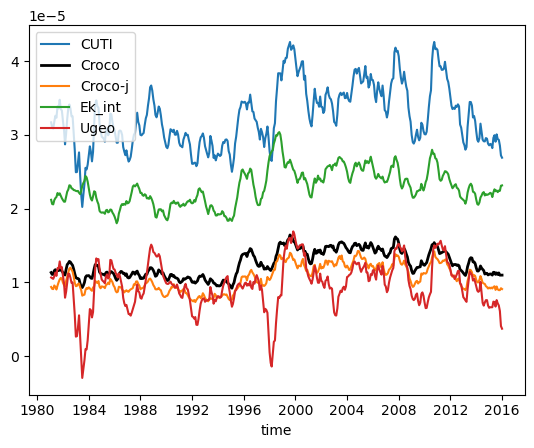

In [38]:
d = (1/12)*10*1000*111

(CUTI/d).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(label='CUTI')
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(label='Croco',linewidth=2,color='black')
wmld_.mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(label='Croco-j')

(((U_ek)).mean(dim='lat_band')/d).rolling(time=13).mean().rename('m/s').plot(label='Ek_int')
(U_geo/d).mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(label='Ugeo')
# (ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat')).rolling(time=13).mean().plot(label='Uekman_crosshore')

plt.legend()

### Seasonality

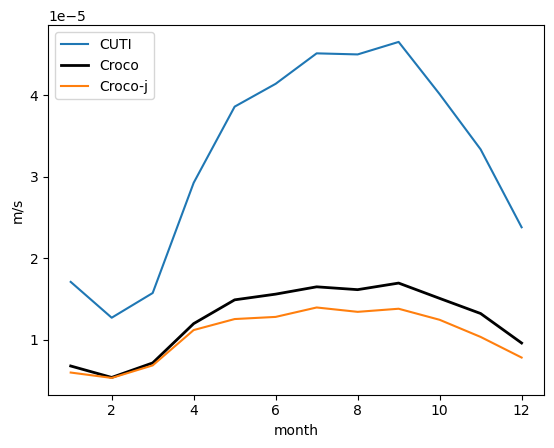

In [39]:
d = (1/12)*10*1000*111

seasonality((CUTI/d).mean(dim=('lon','lat_band'))).plot(label='CUTI')
seasonality(wmld.mean(dim=('lon','lat')).WMLD).rename('m/s').plot(label='Croco',linewidth=2,color='black')
seasonality(wmld_.mean(dim=('lon','lat_band'))).rename('m/s').plot(label='Croco-j')

# (((U_ek)).mean(dim='lat_band')/d).rename('m/s').plot(label='Ek_int')
# seasonality((U_geo*-1/d).mean(dim=('lat_band','lon'))).plot(label='Ugeo')
# seasonality((ds.Uekman_Crossshore*-1/d).mean(dim=('lon','lat'))).plot(label='Uekman_crosshore')

plt.legend()

* Capture doesn't capture mesoescale features because of how is the ugeostrophic velocity built

Text(0.5, 1.0, 'CUTI')

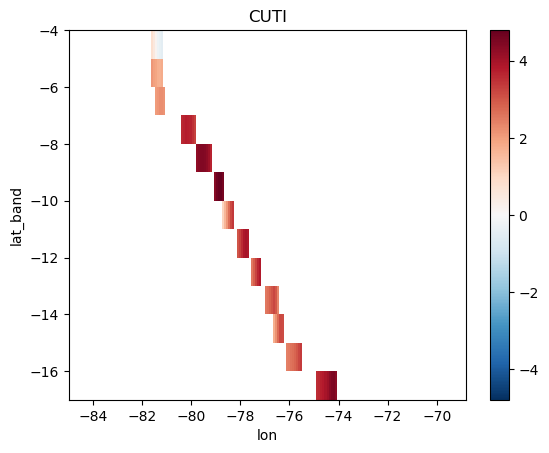

In [40]:
CUTI.mean('time').plot()
plt.title('CUTI')

## BEUTI

In [41]:
nitrogen = xr.open_dataset('Nitrogen.nc').compute()
nitrogen

<xarray.Dataset> Size: 2GB
Dimensions:  (time: 432, lat: 542, lon: 602)
Coordinates:
  * lon      (lon) float64 5kB -119.0 -118.9 -118.8 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 4kB -33.0 -32.93 -32.86 -32.79 ... 9.869 9.951 10.03
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 564MB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0
    TN_mld   (time, lat, lon) float64 1GB 0.1585 0.1588 0.1642 ... 0.0 0.0 0.0

In [42]:
N = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-17,-4))
N

<xarray.Dataset> Size: 160MB
Dimensions:  (time: 432, lat: 159, lon: 194)
Coordinates:
  * lon      (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat      (lat) float64 1kB -16.99 -16.91 -16.83 ... -4.245 -4.162 -4.079
  * time     (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
Data variables:
    TN_surf  (time, lat, lon) float32 53MB nan nan nan nan ... nan nan nan nan
    TN_mld   (time, lat, lon) float64 107MB nan nan nan nan ... nan nan nan nan

In [43]:
N_ = lat_band_mean(N.TN_mld,
    lat_top_start=-5,
    lat_top_end=-16,
)
N_

100%|███████████████████████████████████████████████████████████████████████████████████| 12/12 [00:00<00:00, 870.31it/s]


<xarray.DataArray 'delta_f' (lat_band: 12, time: 432, lon: 194)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5

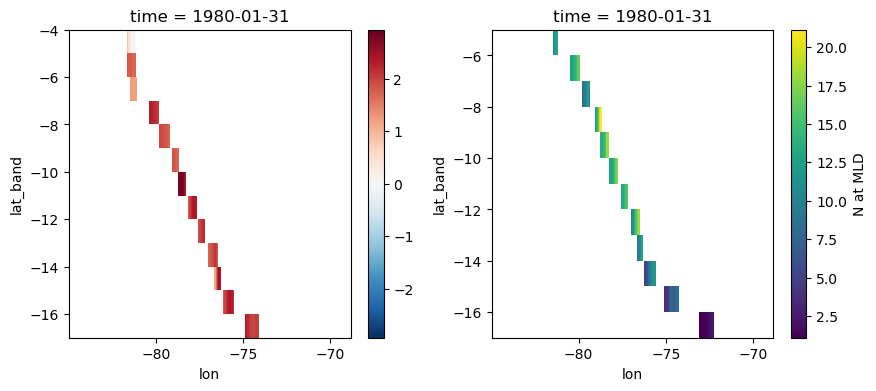

In [44]:
fig,ax = plt.subplots(1,2,figsize=(10,4))
CUTI.isel(time=0).plot(ax=ax[0])
N_.rename('N at MLD').isel(time=0).plot(ax=ax[1])

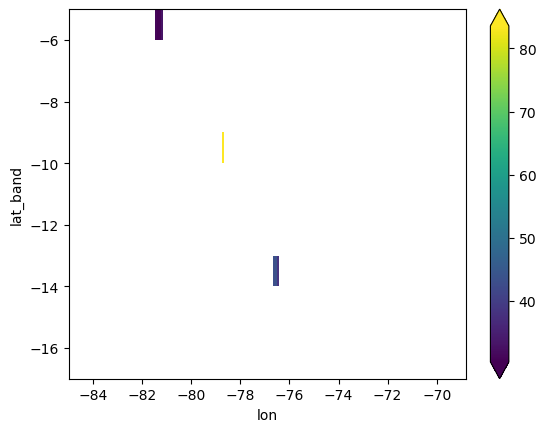

In [45]:
BEUTI = (N_ * CUTI)
(BEUTI).mean('time').plot(robust=True)

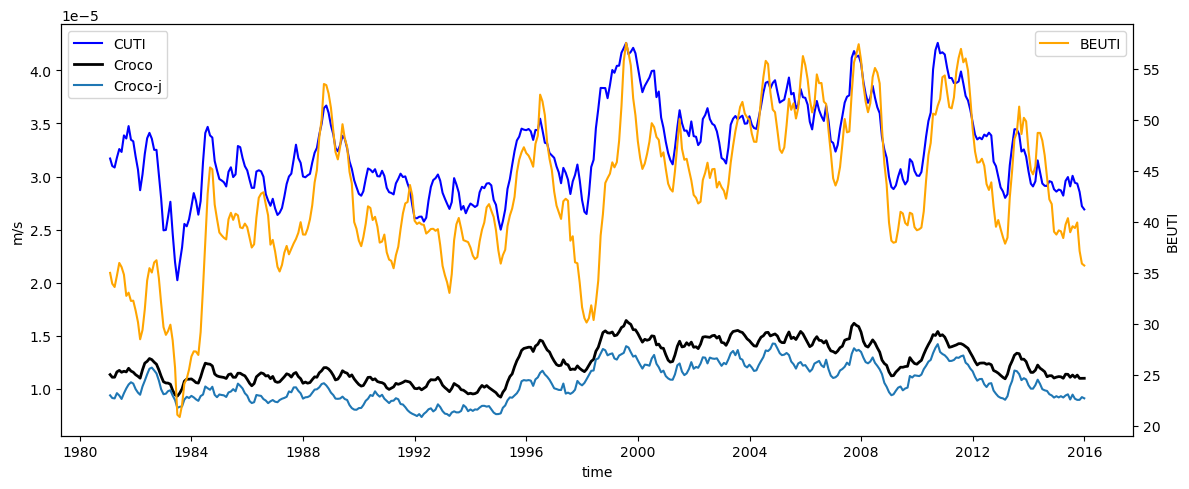

In [46]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis
(CUTI/d).mean(dim=('lon','lat_band')).rolling(time=13).mean().plot(ax=ax1, label='CUTI', color='Blue')
wmld.mean(dim=('lon','lat')).WMLD.rolling(time=13).mean().rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
wmld_.mean(dim=('lon','lat_band')).rolling(time=13).mean().rename('m/s').plot(ax=ax1, label='Croco-j')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

# Right axis for BEUTI
ax2 = ax1.twinx()
BEUTI.mean(dim=('lat_band','lon')).rolling(time=13).mean().plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

plt.tight_layout()

In [47]:
N2 = nitrogen.where(mask_mld).sel(lon=slice(-85,None),lat=slice(-16,-5))

Text(0.5, 1.0, 'Nitrogen Cycle')

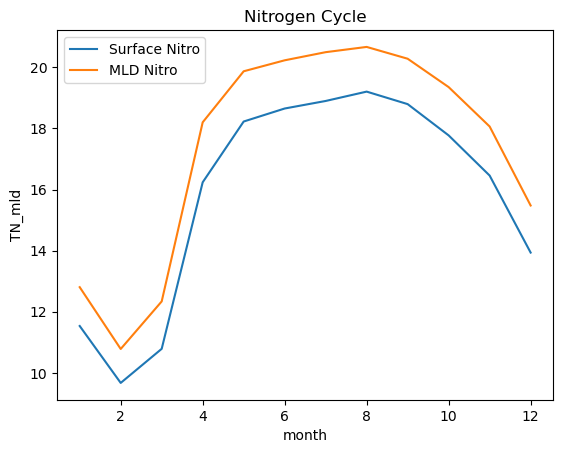

In [48]:
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(label='MLD Nitro')
plt.legend()
plt.title('Nitrogen Cycle')

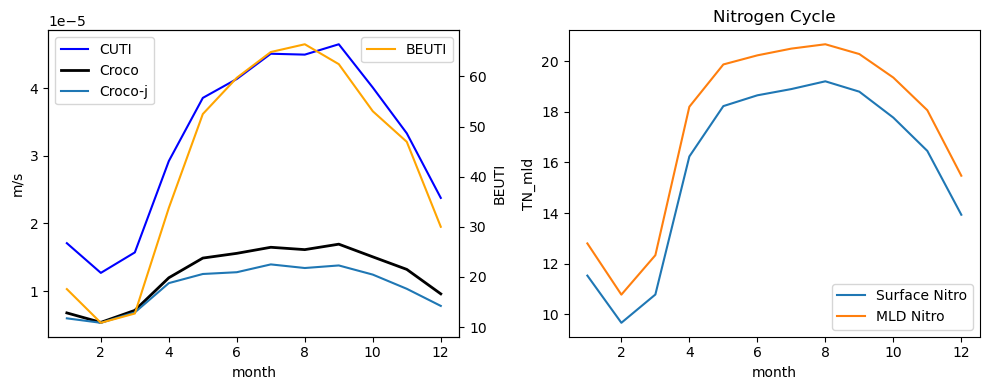

In [49]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(10, 4), sharex=True)

# --- Top panel ---
seasonality((CUTI/d).mean(dim=('lon','lat_band'))).plot(ax=ax1, label='CUTI', color='blue')
seasonality(wmld.mean(dim=('lon','lat')).WMLD).rename('m/s').plot(ax=ax1, label='Croco', linewidth=2, color='black')
seasonality(wmld_.mean(dim=('lon','lat_band'))).rename('m/s').plot(ax=ax1, label='Croco-j')
ax1.set_ylabel('m/s')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
seasonality(BEUTI.mean(dim=('lat_band','lon'))).plot(ax=ax2, label='BEUTI', color='orange')
ax2.set_ylabel('BEUTI')
ax2.legend(loc='upper right')

# --- Bottom panel ---
seasonality(N2.TN_surf).mean(dim=('lat','lon')).plot(ax=ax3, label='Surface Nitro')
seasonality(N2.TN_mld).mean(dim=('lat','lon')).plot(ax=ax3, label='MLD Nitro')
ax3.legend()
ax3.set_title('Nitrogen Cycle')

plt.tight_layout()

* Nitrogen input follows the upwelling season, BEUTI amplifies CUTI in seasonal scales

In [50]:
wmld_ = wmld_.rename('Croco_j')
wmld_

<xarray.DataArray 'Croco_j' (lat_band: 12, time: 432, lon: 194)> Size: 8MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * time      (time) datetime64[ns] 3kB 1980-01-31 1980-02-29 ... 2015-12-31
  * lon       (lon) float64 2kB -84.95 -84.87 -84.78 ... -69.03 -68.95 -68.87
  * lat_band  (lat_band) float64 96B -5.5 -6.5 -7.5 -8.5 ... -14.5 -15.5 -16.5

In [51]:
CUTI = CUTI.to_dataset(name='CUTI')
# CUTI

In [52]:
CUTI['BEUTI'] = BEUTI
CUTI['UGEO'] = U_geo
CUTI['u_geo'] = u_geo
CUTI['U_ek'] = U_ek
CUTI['N_mld'] = N_
CUTI['CROCO_j'] = wmld_

In [53]:
# CUTI.to_netcdf('CUTI_BEUTI_components.nc')